Assignment 2 constants:
K_gen       = 9662263.902001686
omega_rated = 1.0326526034884067
omega_ref   = 1.0826526034884068
V_rated     = 11.510204081632653
Final mechanical power [MW] = 10.639999999999914
Final electrical power [MW] = 10.64
Rated power target [MW]     = 10.64
Assignment 2 turbulent:
Final electrical power [MW] = 3.18279188104472
Mean last 20 s elec. [MW]   = 3.3301591739079437


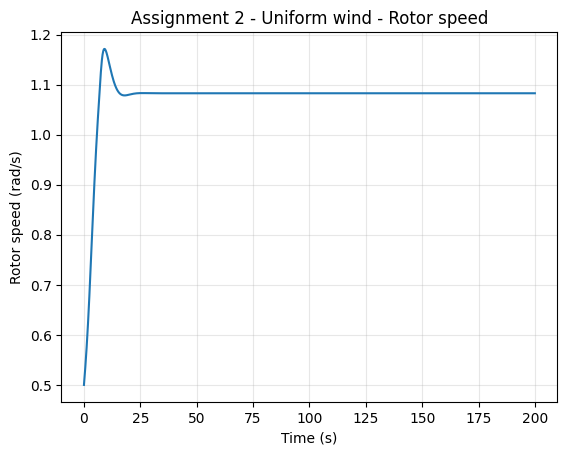

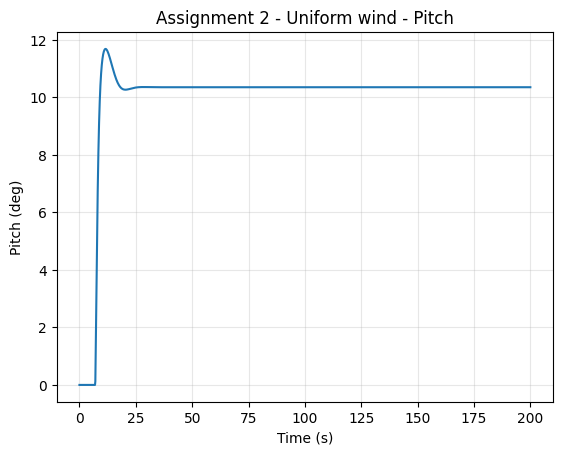

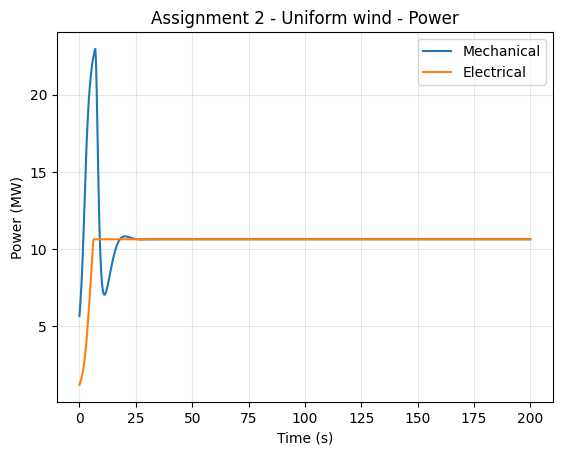

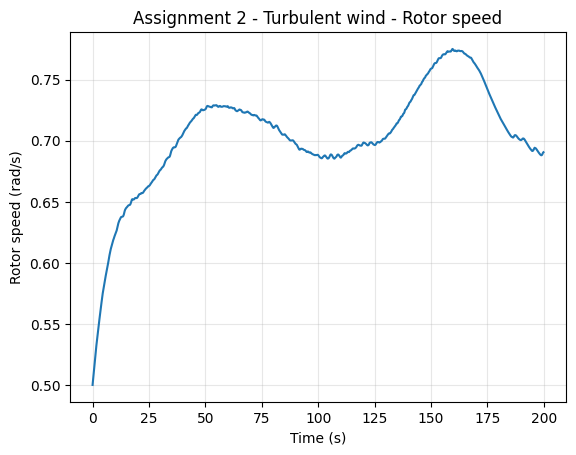

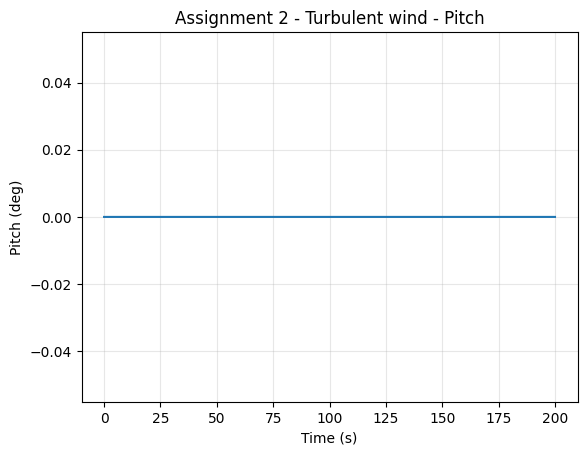

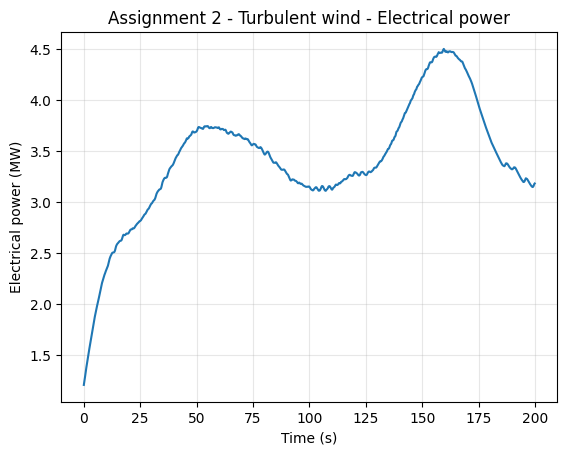

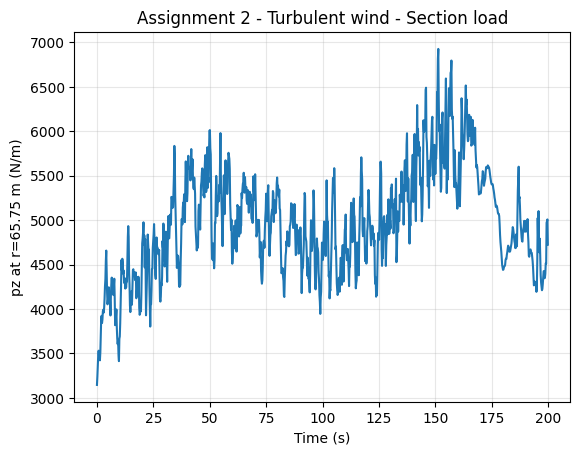

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field

# ============================================================
# 1) FILES
#    Keep all these files in the same folder as this script
# ============================================================

DATA_DIR = "."

BLADE_FILE = os.path.join(DATA_DIR, "bladedat.txt")

AIRFOIL_FILES = {
    100.0: os.path.join(DATA_DIR, "cylinder_ds.txt"),
    24.1:  os.path.join(DATA_DIR, "FFA-W3-241_ds.txt"),
    30.1:  os.path.join(DATA_DIR, "FFA-W3-301_ds.txt"),
    36.0:  os.path.join(DATA_DIR, "FFA-W3-360_ds.txt"),
    48.0:  os.path.join(DATA_DIR, "FFA-W3-480_ds.txt"),
    60.0:  os.path.join(DATA_DIR, "FFA-W3-600_ds.txt"),
}

# Mann turbulence files for Assignment 2 turbulent case
TURB_ZIP_FILE = os.path.join(DATA_DIR, "Turbulence_generator.zip")
TURB_EXTRACT_DIR = os.path.join(DATA_DIR, "Turbulence_generator")
TURB_INP_FILE = os.path.join(TURB_EXTRACT_DIR, "inputEx3.inp")
TURB_U_FILE = os.path.join(DATA_DIR, "sim1.bin")


# ============================================================
# 2) TURBINE + NUMERICAL CONSTANTS
# ============================================================

# Turbine
R = 89.17               # rotor radius [m]
B = 3                   # number of blades
rho = 1.225             # air density [kg/m^3]
H_HUB = 119.0           # hub height [m]

# Grid / time
Nsec = 40               # radial blade sections
WARM_START = True       # use steady induction as initial condition

# BEM solver
F_RELAX = 0.35
TOL_RES = 1e-4
ITMAX = 80

# Assignment 2 controller / drivetrain
P_RATED = 10.64e6       # rated power [W]
I_DRIVETRAIN = 1.6e8    # drivetrain inertia [kg m^2]

K_P = 1.5               # proportional gain
K_I = 0.64              # integral gain
K_K_DEG = 14.0          # gain reduction constant [deg]

THETA_P_MIN_DEG = 0.0
THETA_P_MAX_DEG = 90.0

OMEGA_REF_MARGIN = 0.05  # omega_ref = omega_rated + margin [rad/s]

# Optional pitch actuator model
USE_PITCH_ACTUATOR = False

# Assignment 2 run settings
T_END_A2 = 200.0
DT_A2 = 0.15

# Reference mean wind used for turbulence convection
VHUB_REF = 8.0


# ============================================================
# 3) RECORDERS
# ============================================================

@dataclass
class RecorderA2:
    # Stores time histories for Assignment 2
    t: list = field(default_factory=list)
    omega: list = field(default_factory=list)
    pitch_deg: list = field(default_factory=list)
    T_total: list = field(default_factory=list)
    P_mech_total: list = field(default_factory=list)
    P_el_total: list = field(default_factory=list)
    M_aero: list = field(default_factory=list)
    M_gen: list = field(default_factory=list)

    def record(self, t, omega, pitch_deg, T_total, P_mech_total, P_el_total, M_aero, M_gen):
        self.t.append(float(t))
        self.omega.append(float(omega))
        self.pitch_deg.append(float(pitch_deg))
        self.T_total.append(float(T_total))
        self.P_mech_total.append(float(P_mech_total))
        self.P_el_total.append(float(P_el_total))
        self.M_aero.append(float(M_aero))
        self.M_gen.append(float(M_gen))

    def as_arrays(self):
        return {
            "t": np.array(self.t, dtype=float),
            "omega": np.array(self.omega, dtype=float),
            "pitch_deg": np.array(self.pitch_deg, dtype=float),
            "T_total": np.array(self.T_total, dtype=float),
            "P_mech_total": np.array(self.P_mech_total, dtype=float),
            "P_el_total": np.array(self.P_el_total, dtype=float),
            "M_aero": np.array(self.M_aero, dtype=float),
            "M_gen": np.array(self.M_gen, dtype=float),
        }


# ============================================================
# 4) BLADE GEOMETRY
# ============================================================

def read_bladedat(path):
    """
    Reads blade geometry file:
      col 0 = radius [m]
      col 1 = twist [deg]
      col 2 = chord [m]
      col 3 = thickness ratio t/c [%] or [-]
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing blade file: {path}")

    data = np.loadtxt(path)
    if data.ndim != 2 or data.shape[1] < 4:
        raise ValueError("bladedat.txt must have at least 4 columns")

    r = data[:, 0]
    beta_deg = data[:, 1]
    c = data[:, 2]
    tc = data[:, 3]

    # If t/c is given as ratio instead of percent, convert to percent
    if np.nanmax(tc) <= 1.5:
        tc = tc * 100.0

    idx = np.argsort(r)
    return r[idx], c[idx], beta_deg[idx], tc[idx]


def build_sections(r_tab, c_tab, beta_deg_tab, tc_tab, nsec):
    """
    Interpolates the blade geometry to the radial grid used by BEM
    """
    r0 = float(np.min(r_tab))
    Rtip = float(np.max(r_tab))

    # Stop a little before exact tip to avoid numerical issues
    r_sec = np.linspace(r0, 0.98 * Rtip, nsec)

    c_sec = np.interp(r_sec, r_tab, c_tab)
    beta_deg_sec = np.interp(r_sec, r_tab, beta_deg_tab)
    tc_sec = np.interp(r_sec, r_tab, tc_tab)

    return Rtip, r_sec, c_sec, beta_deg_sec, tc_sec


# ============================================================
# 5) AIRFOIL POLARS
# ============================================================

def read_polar_file(path):
    """
    Reads one airfoil polar file:
      col 0 = alpha [deg]
      col 1 = Cl
      col 2 = Cd
    """
    tbl = np.loadtxt(path, ndmin=2)
    if tbl.shape[1] < 3:
        raise ValueError(f"{path} must have >= 3 columns")

    alpha = tbl[:, 0]
    cl = tbl[:, 1]
    cd = tbl[:, 2]

    order = np.argsort(alpha)
    return alpha[order], cl[order], cd[order]


def load_airfoils(files_dict):
    """
    Loads all airfoil tables and stores them by thickness
    """
    items = sorted(files_dict.items(), key=lambda kv: kv[0])
    thick = np.array([tc for tc, _ in items], dtype=float)

    aoa_cols, cl_cols, cd_cols = [], [], []
    for tc, fname in items:
        if not os.path.exists(fname):
            raise FileNotFoundError(f"Missing airfoil file: {fname}")
        a, cl, cd = read_polar_file(fname)
        aoa_cols.append(a)
        cl_cols.append(cl)
        cd_cols.append(cd)

    return thick, aoa_cols, cl_cols, cd_cols


THICK, AOA_COLS, CL_COLS, CD_COLS = load_airfoils(AIRFOIL_FILES)


def interp_extrap(x, xp, yp):
    """
    1D interpolation with linear extrapolation outside the tabulated range
    """
    x = float(x)
    xp = np.asarray(xp, dtype=float)
    yp = np.asarray(yp, dtype=float)

    if x <= xp[0]:
        x0, x1 = xp[0], xp[1]
        y0, y1 = yp[0], yp[1]
        return y0 + (y1 - y0) * (x - x0) / (x1 - x0)

    if x >= xp[-1]:
        x0, x1 = xp[-2], xp[-1]
        y0, y1 = yp[-2], yp[-1]
        return y1 + (y1 - y0) * (x - x1) / (x1 - x0)

    return float(np.interp(x, xp, yp))


def cl_cd_double_interp(alpha_deg, tc_percent):
    """
    Two-step interpolation:
    1) interpolate Cl and Cd in angle of attack for each airfoil thickness
    2) interpolate in thickness to get the local section values
    """
    tc = float(np.clip(tc_percent, THICK.min(), THICK.max()))

    cl_thk = np.empty(len(THICK))
    cd_thk = np.empty(len(THICK))

    for k in range(len(THICK)):
        cl_thk[k] = interp_extrap(alpha_deg, AOA_COLS[k], CL_COLS[k])
        cd_thk[k] = interp_extrap(alpha_deg, AOA_COLS[k], CD_COLS[k])

    cl = float(np.interp(tc, THICK, cl_thk))
    cd = float(np.interp(tc, THICK, cd_thk))
    return cl, cd


# ============================================================
# 6) BEM AERODYNAMICS
# ============================================================

def prandtl_tip_loss(B, r, R, phi):
    """
    Prandtl tip-loss factor
    """
    sphi = max(abs(np.sin(phi)), 1e-12)
    ftip = max((B * (R - r)) / (2.0 * r * sphi), 0.0)
    F = (2.0 / np.pi) * np.arccos(np.exp(-ftip))
    return float(np.clip(F, 1e-6, 1.0))


def solve_a_ap_qs(V0, Omega, r, chord, twist_deg, pitch_deg, tc_percent, a_init, ap_init):
    """
    Quasi-steady BEM iteration for:
      a  = axial induction factor
      ap = tangential induction factor

    Main equations:
      phi   = atan((1-a)V0 / ((1+ap)Omega r))
      alpha = phi - (twist + pitch)

      Lift and drag are projected into:
      fN = normal load per span
      fT = tangential load per span
    """
    theta_p = np.deg2rad(pitch_deg)
    twist = np.deg2rad(twist_deg)

    a_new = 0.10 if a_init == 0.0 else a_init
    ap_new = 0.00 if ap_init == 0.0 else ap_init

    it = 0
    while True:
        it += 1
        a, ap = a_new, ap_new

        denom = (1.0 + ap) * Omega * r + 1e-12
        phi = np.arctan(((1.0 - a) * V0) / denom)
        alpha_deg = np.rad2deg(phi - (twist + theta_p))

        Cl, Cd = cl_cd_double_interp(alpha_deg, tc_percent)

        Cn = Cl * np.cos(phi) + Cd * np.sin(phi)
        Ct = Cl * np.sin(phi) - Cd * np.cos(phi)

        sigma = (B * chord) / (2.0 * np.pi * r + 1e-12)
        F = prandtl_tip_loss(B, r, R, phi)

        sphi = np.sin(phi)
        cphi = np.cos(phi)

        a_fix = (sigma * Cn * (1.0 - a)) / (4.0 * F * sphi**2 + 1e-12)
        ap_fix = (sigma * Ct * (1.0 + ap)) / (4.0 * F * sphi * cphi + 1e-12)

        # High-thrust correction
        if a > 0.33:
            dCT = ((1.0 - a)**2 * Cn * sigma) / (sphi**2 + 1e-12)
            a_fix = dCT / (4.0 * F * (1.0 - 0.25 * (5.0 - 3.0 * a) * a) + 1e-12)

        a_new = a + F_RELAX * (a_fix - a)
        ap_new = ap + F_RELAX * (ap_fix - ap)

        if max(abs(a_fix - a), abs(ap_fix - ap)) < TOL_RES or it >= ITMAX:
            return a_new, ap_new


def loads_from_a_ap(V0, Omega, r, chord, twist_deg, pitch_deg, tc_percent, a, ap):
    """
    Computes section loads from solved induction factors

    Relative wind:
      Vrel = sqrt(((1-a)V0)^2 + ((1+ap)Omega r)^2)

    Lift:
      L = 0.5 rho Vrel^2 c Cl

    Drag:
      D = 0.5 rho Vrel^2 c Cd

    Project to rotor-normal and rotor-tangential directions:
      fN = L cos(phi) + D sin(phi)
      fT = L sin(phi) - D cos(phi)
    """
    theta_p = np.deg2rad(pitch_deg)
    twist = np.deg2rad(twist_deg)

    denom = (1.0 + ap) * Omega * r + 1e-12
    phi = np.arctan(((1.0 - a) * V0) / denom)
    alpha_deg = np.rad2deg(phi - (twist + theta_p))

    Cl, Cd = cl_cd_double_interp(alpha_deg, tc_percent)

    Vrel = np.sqrt(((1.0 - a) * V0)**2 + ((1.0 + ap) * Omega * r)**2)
    L = 0.5 * rho * Vrel**2 * chord * Cl
    D = 0.5 * rho * Vrel**2 * chord * Cd

    fT = L * np.sin(phi) - D * np.cos(phi)
    fN = L * np.cos(phi) + D * np.sin(phi)

    return fN, fT


def compute_blade_thrust_torque_power(fN, fT, r_sec, Omega):
    """
    Integrates section loads to get blade thrust, torque, and mechanical power
    """
    Tblade = np.trapezoid(fN, r_sec)
    Qblade = np.trapezoid(fT * r_sec, r_sec)
    Pblade = Omega * Qblade
    return Tblade, Qblade, Pblade


def warm_start_induction(a_state, ap_state, r_sec, c_sec, beta_deg_sec, tc_sec, Vz_local, pitch_deg, Omega):
    """
    Initializes induction factors by solving steady BEM once at each section
    """
    for j in range(len(r_sec)):
        a_state[j], ap_state[j] = solve_a_ap_qs(
            Vz_local[j], Omega, r_sec[j], c_sec[j], beta_deg_sec[j], pitch_deg, tc_sec[j],
            a_state[j], ap_state[j]
        )


# ============================================================
# 7) ASSIGNMENT 2 CONTROLLER + GENERATOR
# ============================================================

def generator_torque(Omega, K_gen, Omega_rated, P_rated):
    """
    Generator torque law

    Below rated:
      M_gen = K * Omega^2

    Above rated:
      M_gen = P_rated / Omega
    """
    Omega_eff = max(float(Omega), 1e-6)

    if Omega_eff < Omega_rated:
        return K_gen * Omega_eff**2
    return P_rated / Omega_eff


def electrical_power(M_gen, Omega):
    """
    Electrical power:
      P_el = M_gen * Omega
    """
    return M_gen * Omega


def pitch_controller_step(theta_int_deg, Omega, Omega_ref, dt):
    """
    Simple PI collective pitch controller

    Speed error:
      e = Omega - Omega_ref

    Pitch command = proportional part + integral part
    Gain reduction is included through K_K_DEG
    """
    err = Omega - Omega_ref

    gain_reduction = 1.0 + max(theta_int_deg, 0.0) / max(K_K_DEG, 1e-6)

    theta_p_term_deg = np.rad2deg(K_P * err) / gain_reduction
    theta_int_deg_new = theta_int_deg + np.rad2deg(K_I * err * dt) / gain_reduction

    theta_int_deg_new = np.clip(theta_int_deg_new, THETA_P_MIN_DEG, THETA_P_MAX_DEG)

    theta_set_deg = theta_p_term_deg + theta_int_deg_new
    theta_set_deg = np.clip(theta_set_deg, THETA_P_MIN_DEG, THETA_P_MAX_DEG)

    return theta_set_deg, theta_int_deg_new


def steady_power_for_operating_point(V0, Omega, pitch_deg, r_sec, c_sec, beta_deg_sec, tc_sec):
    """
    Computes total aerodynamic power at one steady operating point
    Used to estimate rated operating condition
    """
    a_state = np.zeros(len(r_sec))
    ap_state = np.zeros(len(r_sec))
    Vz_local = np.full_like(r_sec, V0)

    if WARM_START:
        warm_start_induction(a_state, ap_state, r_sec, c_sec, beta_deg_sec, tc_sec, Vz_local, pitch_deg, Omega)

    fN = np.zeros_like(r_sec)
    fT = np.zeros_like(r_sec)

    for j in range(len(r_sec)):
        a_qs, ap_qs = solve_a_ap_qs(
            V0, Omega, r_sec[j], c_sec[j], beta_deg_sec[j], pitch_deg, tc_sec[j],
            a_state[j], ap_state[j]
        )
        a_state[j], ap_state[j] = a_qs, ap_qs

        fN[j], fT[j] = loads_from_a_ap(
            V0, Omega, r_sec[j], c_sec[j], beta_deg_sec[j], pitch_deg, tc_sec[j],
            a_state[j], ap_state[j]
        )

    _, Qblade, _ = compute_blade_thrust_torque_power(fN, fT, r_sec, Omega)
    Qaero_total = B * Qblade
    Paero_total = Qaero_total * Omega
    return Paero_total


def find_rated_operating_point(r_sec, c_sec, beta_deg_sec, tc_sec,
                               lambda_opt=8.0, v_min=4.0, v_max=20.0, nV=50):
    """
    Finds approximate rated operating point by sweeping wind speed
    assuming optimal TSR below rated

    Continuity of generator law at rated gives:
      K = P_rated / Omega_rated^3
    """
    V_vec = np.linspace(v_min, v_max, nV)
    P_vec = np.zeros_like(V_vec)

    for i, V0 in enumerate(V_vec):
        Omega = lambda_opt * V0 / R
        P_vec[i] = steady_power_for_operating_point(
            V0, Omega, 0.0, r_sec, c_sec, beta_deg_sec, tc_sec
        )

    idx = np.argmax(P_vec >= P_RATED)
    if P_vec[idx] < P_RATED:
        raise RuntimeError("Could not find rated wind speed in chosen sweep")

    V_rated = V_vec[idx]
    Omega_rated = lambda_opt * V_rated / R
    K_gen = P_RATED / (Omega_rated**3)
    Omega_ref = Omega_rated + OMEGA_REF_MARGIN

    return {
        "V_rated": V_rated,
        "Omega_rated": Omega_rated,
        "Omega_ref": Omega_ref,
        "K_gen": K_gen,
        "V_vec": V_vec,
        "P_vec": P_vec,
    }


# ============================================================
# 8) TURBULENCE INPUTS
# ============================================================

def ensure_turbulence_files_exist():
    """
    Makes sure sim1.bin exists.
    If not present directly, tries to extract it from the turbulence zip.
    """
    if os.path.exists(TURB_U_FILE):
        return

    if not os.path.exists(TURB_ZIP_FILE):
        raise FileNotFoundError(
            "No sim1.bin found, and Turbulence_generator.zip is also missing."
        )

    os.makedirs(TURB_EXTRACT_DIR, exist_ok=True)

    import zipfile
    with zipfile.ZipFile(TURB_ZIP_FILE, "r") as zf:
        zf.extractall(DATA_DIR)

    sim1_extracted = os.path.join(TURB_EXTRACT_DIR, "sim1.bin")
    if not os.path.exists(sim1_extracted):
        raise FileNotFoundError("Could not find sim1.bin after extracting the zip.")

    if not os.path.exists(TURB_U_FILE):
        try:
            import shutil
            shutil.copy(sim1_extracted, TURB_U_FILE)
        except Exception:
            pass


def read_mann_inp(path):
    """
    Reads dimensions of the Mann turbulence box from inputEx3.inp
    """
    if not os.path.exists(path):
        return None

    lines = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for ln in f:
            ln = ln.strip()
            if ln:
                lines.append(ln)

    if len(lines) < 10:
        return None

    n1 = int(float(lines[3]))
    n2 = int(float(lines[4]))
    n3 = int(float(lines[5]))

    Lx = float(lines[6])
    Ly = float(lines[7])
    Lz = float(lines[8])

    return {
        "n1": n1,
        "n2": n2,
        "n3": n3,
        "Lx": Lx,
        "Ly": Ly,
        "Lz": Lz,
    }


def load_mann_bin_3d(filename, n1, n2, n3):
    """
    Loads Mann turbulence binary file as float32 array with shape (n1, n2, n3)
    """
    data = np.fromfile(filename, dtype=np.dtype("<f4"), count=n1 * n2 * n3)
    if data.size != n1 * n2 * n3:
        raise ValueError(f"{filename} size does not match n1*n2*n3")
    return data.reshape((n1, n2, n3), order="C")


def bilinear_interp_plane(u_plane, y_grid, z_grid, y_pos, z_pos):
    """
    Bilinear interpolation in the current turbulence plane
    """
    y_grid = np.asarray(y_grid, dtype=float)
    z_grid = np.asarray(z_grid, dtype=float)
    y_pos = np.asarray(y_pos, dtype=float)
    z_pos = np.asarray(z_pos, dtype=float)

    ny = len(y_grid)
    nz = len(z_grid)

    y_pos_c = np.clip(y_pos, y_grid[0], y_grid[-1])
    z_pos_c = np.clip(z_pos, z_grid[0], z_grid[-1])

    iy = np.searchsorted(y_grid, y_pos_c) - 1
    iz = np.searchsorted(z_grid, z_pos_c) - 1

    iy = np.clip(iy, 0, ny - 2)
    iz = np.clip(iz, 0, nz - 2)

    y0 = y_grid[iy]
    y1 = y_grid[iy + 1]
    z0 = z_grid[iz]
    z1 = z_grid[iz + 1]

    ty = (y_pos_c - y0) / np.maximum(y1 - y0, 1e-12)
    tz = (z_pos_c - z0) / np.maximum(z1 - z0, 1e-12)

    v00 = u_plane[iy,     iz]
    v10 = u_plane[iy + 1, iz]
    v01 = u_plane[iy,     iz + 1]
    v11 = u_plane[iy + 1, iz + 1]

    v0 = v00 * (1.0 - ty) + v10 * ty
    v1 = v01 * (1.0 - ty) + v11 * ty
    return v0 * (1.0 - tz) + v1 * tz


# ============================================================
# 9) ASSIGNMENT 2 - UNIFORM WIND
# ============================================================

def run_A2_uniform(r_sec, c_sec, beta_deg_sec, tc_sec,
                   V0=15.0,
                   omega_init=0.5,
                   pitch_init_deg=0.0,
                   T_end=T_END_A2,
                   dt=DT_A2):
    """
    Assignment 2, Question 1:
    Uniform wind + dynamic rotor speed + PI pitch controller
    """
    rated = find_rated_operating_point(r_sec, c_sec, beta_deg_sec, tc_sec)
    K_gen = rated["K_gen"]
    omega_rated = rated["Omega_rated"]
    omega_ref = rated["Omega_ref"]

    n_steps = int(np.floor(T_end / dt)) + 1

    a_state = np.zeros(len(r_sec))
    ap_state = np.zeros(len(r_sec))

    omega_t = omega_init
    pitch_deg = pitch_init_deg
    theta_int_deg = pitch_init_deg

    Vz_local = np.full_like(r_sec, V0)

    if WARM_START:
        warm_start_induction(
            a_state, ap_state,
            r_sec, c_sec, beta_deg_sec, tc_sec,
            Vz_local, pitch_deg, omega_t
        )

    rec = RecorderA2()

    for k in range(n_steps):
        t = k * dt

        fN = np.zeros_like(r_sec)
        fT = np.zeros_like(r_sec)

        for j in range(len(r_sec)):
            a_qs, ap_qs = solve_a_ap_qs(
                V0, omega_t, r_sec[j], c_sec[j], beta_deg_sec[j], pitch_deg, tc_sec[j],
                a_state[j], ap_state[j]
            )
            a_state[j], ap_state[j] = a_qs, ap_qs

            fN[j], fT[j] = loads_from_a_ap(
                V0, omega_t, r_sec[j], c_sec[j], beta_deg_sec[j], pitch_deg, tc_sec[j],
                a_state[j], ap_state[j]
            )

        Tblade, Qblade, Pblade = compute_blade_thrust_torque_power(fN, fT, r_sec, omega_t)

        T_total = B * Tblade
        M_aero = B * Qblade
        P_mech_total = B * Pblade

        M_gen = generator_torque(omega_t, K_gen, omega_rated, P_RATED)
        P_el_total = electrical_power(M_gen, omega_t)

        # Rotor speed equation:
        # I * domega/dt = M_aero - M_gen
        domega_dt = (M_aero - M_gen) / I_DRIVETRAIN
        omega_next = max(0.0, omega_t + dt * domega_dt)

        # Pitch control only used near and above rated
        if omega_t >= omega_rated:
            pitch_next_deg, theta_int_deg = pitch_controller_step(
                theta_int_deg, omega_t, omega_ref, dt
            )
        else:
            pitch_next_deg = 0.0
            theta_int_deg = 0.0

        pitch_next_deg = float(np.clip(pitch_next_deg, THETA_P_MIN_DEG, THETA_P_MAX_DEG))

        rec.record(t, omega_t, pitch_deg, T_total, P_mech_total, P_el_total, M_aero, M_gen)

        pitch_deg = pitch_next_deg
        omega_t = omega_next

    out = rec.as_arrays()
    out["K_gen"] = K_gen
    out["omega_rated"] = omega_rated
    out["omega_ref"] = omega_ref
    out["V_rated"] = rated["V_rated"]
    return out


# ============================================================
# 10) ASSIGNMENT 2 - TURBULENT WIND
# ============================================================

def run_A2_turbulent(r_sec, c_sec, beta_deg_sec, tc_sec,
                     omega_init=0.5,
                     pitch_init_deg=0.0,
                     r_probe=65.75,
                     T_end=T_END_A2):
    """
    Assignment 2, Question 2:
    Turbulent inflow + dynamic rotor speed + PI pitch controller
    """
    ensure_turbulence_files_exist()

    rated = find_rated_operating_point(r_sec, c_sec, beta_deg_sec, tc_sec)
    K_gen = rated["K_gen"]
    omega_rated = rated["Omega_rated"]
    omega_ref = rated["Omega_ref"]

    inp = read_mann_inp(TURB_INP_FILE)
    if inp is None:
        n1, n2, n3 = 4096, 32, 32
        Lx, Ly, Lz = 6142.5, 180.0, 180.0
    else:
        n1, n2, n3 = inp["n1"], inp["n2"], inp["n3"]
        Lx, Ly, Lz = inp["Lx"], inp["Ly"], inp["Lz"]

    ufile = TURB_U_FILE
    if not os.path.exists(ufile):
        ufile2 = os.path.join(TURB_EXTRACT_DIR, "sim1.bin")
        if os.path.exists(ufile2):
            ufile = ufile2
        else:
            raise FileNotFoundError("Could not find sim1.bin")

    u_box = load_mann_bin_3d(ufile, n1, n2, n3)

    dx = Lx / (n1 - 1)
    dy = Ly / (n2 - 1)
    dz = Lz / (n3 - 1)

    # Frozen turbulence timestep:
    # dt = dx / U_mean
    dt_turb = dx / max(VHUB_REF, 0.1)

    y_grid = (np.arange(n2) * dy) - ((n2 - 1) * dy) / 2.0
    z_grid = H_HUB + (np.arange(n3) * dz) - ((n3 - 1) * dz) / 2.0

    n_steps = int(np.floor(T_end / dt_turb)) + 1
    n_steps = min(n_steps, n1)

    a_state = np.zeros((B, len(r_sec)))
    ap_state = np.zeros((B, len(r_sec)))

    omega_t = omega_init
    pitch_deg = pitch_init_deg
    theta_int_deg = pitch_init_deg

    if WARM_START:
        for b in range(B):
            Vz_local_ws = wind_constant(r_sec, VHUB_REF)
            warm_start_induction(
                a_state[b], ap_state[b],
                r_sec, c_sec, beta_deg_sec, tc_sec,
                Vz_local_ws, pitch_deg, omega_t
            )

    rec = RecorderA2()
    pz_probe_hist = []

    for n in range(n_steps):
        t = n * dt_turb
        u_plane = u_box[n, :, :]

        T_b = np.zeros(B)
        Q_b = np.zeros(B)

        for b in range(B):
            azim = omega_t * t + 2.0 * np.pi * b / B

            # Blade section position in rotor plane
            y_pos = r_sec * np.sin(azim)
            z_pos = H_HUB + r_sec * np.cos(azim)

            # Local turbulent axial wind
            u_turb = bilinear_interp_plane(u_plane, y_grid, z_grid, y_pos, z_pos)
            Vz_local = np.maximum(VHUB_REF + u_turb, 0.1)

            fN = np.zeros_like(r_sec)
            fT = np.zeros_like(r_sec)

            for j in range(len(r_sec)):
                a_qs, ap_qs = solve_a_ap_qs(
                    Vz_local[j], omega_t, r_sec[j], c_sec[j], beta_deg_sec[j], pitch_deg, tc_sec[j],
                    a_state[b, j], ap_state[b, j]
                )
                a_state[b, j], ap_state[b, j] = a_qs, ap_qs

                fN[j], fT[j] = loads_from_a_ap(
                    Vz_local[j], omega_t, r_sec[j], c_sec[j], beta_deg_sec[j], pitch_deg, tc_sec[j],
                    a_state[b, j], ap_state[b, j]
                )

            T_b[b], Q_b[b], _ = compute_blade_thrust_torque_power(fN, fT, r_sec, omega_t)

            if b == 0:
                pz_probe_hist.append(np.interp(r_probe, r_sec, fN))

        T_total = np.sum(T_b)
        M_aero = np.sum(Q_b)
        P_mech_total = M_aero * omega_t

        M_gen = generator_torque(omega_t, K_gen, omega_rated, P_RATED)
        P_el_total = electrical_power(M_gen, omega_t)

        domega_dt = (M_aero - M_gen) / I_DRIVETRAIN
        omega_next = max(0.0, omega_t + dt_turb * domega_dt)

        if omega_t >= omega_rated:
            pitch_next_deg, theta_int_deg = pitch_controller_step(
                theta_int_deg, omega_t, omega_ref, dt_turb
            )
        else:
            pitch_next_deg = 0.0
            theta_int_deg = 0.0

        pitch_next_deg = float(np.clip(pitch_next_deg, THETA_P_MIN_DEG, THETA_P_MAX_DEG))

        rec.record(t, omega_t, pitch_deg, T_total, P_mech_total, P_el_total, M_aero, M_gen)

        pitch_deg = pitch_next_deg
        omega_t = omega_next

    out = rec.as_arrays()
    out["K_gen"] = K_gen
    out["omega_rated"] = omega_rated
    out["omega_ref"] = omega_ref
    out["V_rated"] = rated["V_rated"]
    out["dt_turb"] = dt_turb
    out["pz_probe"] = np.array(pz_probe_hist, dtype=float)
    return out


# ============================================================
# 11) PLOTS USED FOR ASSIGNMENT 2
# ============================================================

def plot_A2_uniform(out):
    outdir = "pdf_plots"
    os.makedirs(outdir, exist_ok=True)

    plt.figure()
    plt.plot(out["t"], out["omega"])
    plt.xlabel("Time (s)")
    plt.ylabel("Rotor speed (rad/s)")
    plt.title("Assignment 2 - Uniform wind - Rotor speed")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(outdir, "A2_uniform_omega.pdf"), bbox_inches="tight")

    plt.figure()
    plt.plot(out["t"], out["pitch_deg"])
    plt.xlabel("Time (s)")
    plt.ylabel("Pitch (deg)")
    plt.title("Assignment 2 - Uniform wind - Pitch")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(outdir, "A2_uniform_pitch.pdf"), bbox_inches="tight")

    plt.figure()
    plt.plot(out["t"], out["P_mech_total"] / 1e6, label="Mechanical")
    plt.plot(out["t"], out["P_el_total"] / 1e6, label="Electrical")
    plt.xlabel("Time (s)")
    plt.ylabel("Power (MW)")
    plt.title("Assignment 2 - Uniform wind - Power")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(outdir, "A2_uniform_power.pdf"), bbox_inches="tight")


def plot_A2_turbulent(out):
    outdir = "pdf_plots"
    os.makedirs(outdir, exist_ok=True)

    plt.figure()
    plt.plot(out["t"], out["omega"])
    plt.xlabel("Time (s)")
    plt.ylabel("Rotor speed (rad/s)")
    plt.title("Assignment 2 - Turbulent wind - Rotor speed")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(outdir, "A2_turbulent_omega.pdf"), bbox_inches="tight")

    plt.figure()
    plt.plot(out["t"], out["pitch_deg"])
    plt.xlabel("Time (s)")
    plt.ylabel("Pitch (deg)")
    plt.title("Assignment 2 - Turbulent wind - Pitch")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(outdir, "A2_turbulent_pitch.pdf"), bbox_inches="tight")

    plt.figure()
    plt.plot(out["t"], out["P_el_total"] / 1e6)
    plt.xlabel("Time (s)")
    plt.ylabel("Electrical power (MW)")
    plt.title("Assignment 2 - Turbulent wind - Electrical power")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(outdir, "A2_turbulent_power.pdf"), bbox_inches="tight")

    plt.figure()
    plt.plot(out["t"], out["pz_probe"])
    plt.xlabel("Time (s)")
    plt.ylabel("pz at r=65.75 m (N/m)")
    plt.title("Assignment 2 - Turbulent wind - Section load")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(outdir, "A2_turbulent_pz.pdf"), bbox_inches="tight")


# ============================================================
# 12) MAIN
# ============================================================

def main():
    # Read blade geometry and create radial grid
    r_tab, c_tab, beta_deg_tab, tc_tab = read_bladedat(BLADE_FILE)
    _, r_sec, c_sec, beta_deg_sec, tc_sec = build_sections(
        r_tab, c_tab, beta_deg_tab, tc_tab, Nsec
    )

    # --------------------------------------------------------
    # Assignment 2 - Question 1: uniform wind
    # --------------------------------------------------------
    out_uniform = run_A2_uniform(
        r_sec, c_sec, beta_deg_sec, tc_sec,
        V0=15.0,
        omega_init=0.5,
        pitch_init_deg=0.0
    )
    plot_A2_uniform(out_uniform)

    # --------------------------------------------------------
    # Assignment 2 - Question 2: turbulent wind
    # --------------------------------------------------------
    out_turb = run_A2_turbulent(
        r_sec, c_sec, beta_deg_sec, tc_sec,
        omega_init=0.5,
        pitch_init_deg=0.0,
        r_probe=65.75
    )
    plot_A2_turbulent(out_turb)

    # Print useful values for report / debugging
    print("Assignment 2 constants:")
    print("K_gen       =", out_uniform["K_gen"])
    print("omega_rated =", out_uniform["omega_rated"])
    print("omega_ref   =", out_uniform["omega_ref"])
    print("V_rated     =", out_uniform["V_rated"])
    print("Final mechanical power [MW] =", out_uniform["P_mech_total"][-1] / 1e6)
    print("Final electrical power [MW] =", out_uniform["P_el_total"][-1] / 1e6)
    print("Rated power target [MW]     =", P_RATED / 1e6)

    print("Assignment 2 turbulent:")
    print("Final electrical power [MW] =", out_turb["P_el_total"][-1] / 1e6)
    print("Mean last 20 s elec. [MW]   =", np.mean(out_turb["P_el_total"][-int(20.0 / out_turb["dt_turb"]):]) / 1e6)

    plt.show()


if __name__ == "__main__":
    main()

Assignment 2 constants:
K_gen       = 9662263.902001686
omega_rated = 1.0326526034884067
omega_ref   = 1.0826526034884068
V_rated     = 11.510204081632653

Example above-rated case at 15 m/s:
Final mechanical power [MW] = 10.639999999999914
Final electrical power [MW] = 10.64
Final pitch [deg]           = 10.353808796256555
Rated power target [MW]     = 10.64

Below-rated sweep:
V=6.0 m/s, omega=0.5390 rad/s, pitch=0.000 deg, TSR=8.010, Cp=0.4578
V=8.0 m/s, omega=0.7186 rad/s, pitch=0.000 deg, TSR=8.010, Cp=0.4578
V=10.0 m/s, omega=0.8983 rad/s, pitch=0.000 deg, TSR=8.010, Cp=0.4578

Above-rated sweep:
V=12.0 m/s, pitch=4.392 deg, omega=1.0827 rad/s, P_el=10.6400 MW
V=14.0 m/s, pitch=8.799 deg, omega=1.0827 rad/s, P_el=10.6400 MW
V=16.0 m/s, pitch=11.751 deg, omega=1.0827 rad/s, P_el=10.6400 MW
V=18.0 m/s, pitch=14.244 deg, omega=1.0827 rad/s, P_el=10.6400 MW
V=20.0 m/s, pitch=16.491 deg, omega=1.0827 rad/s, P_el=10.6400 MW

Assignment 2 turbulent:
Final electrical power [MW] = 3.18279

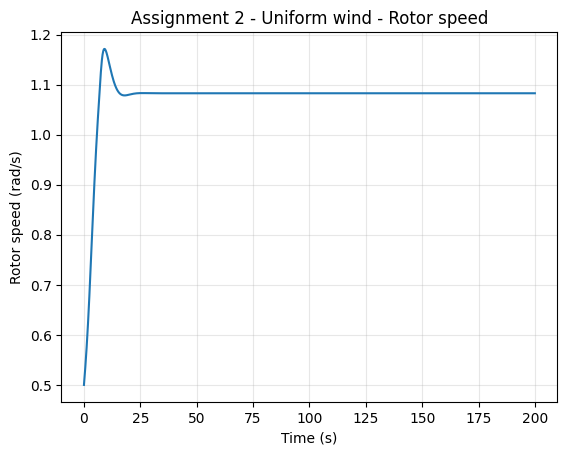

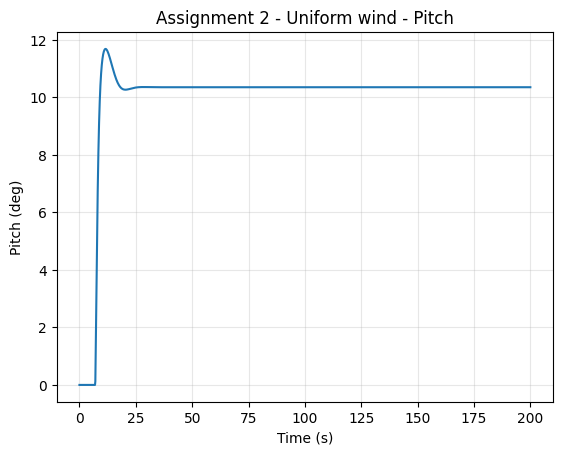

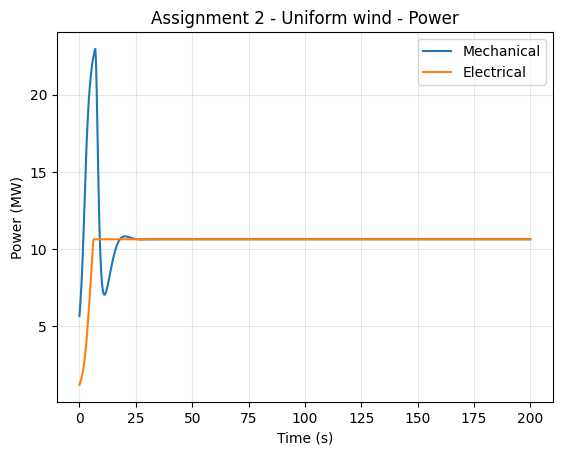

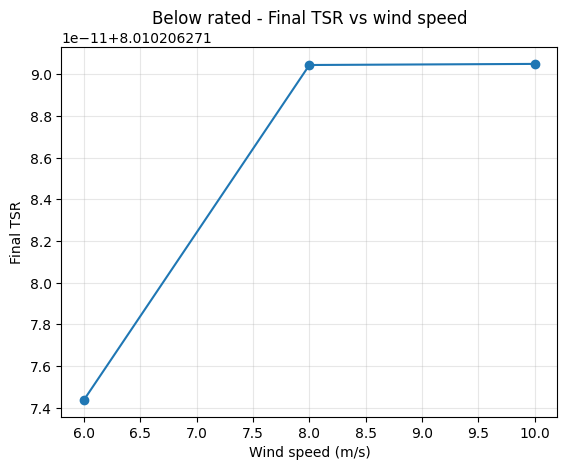

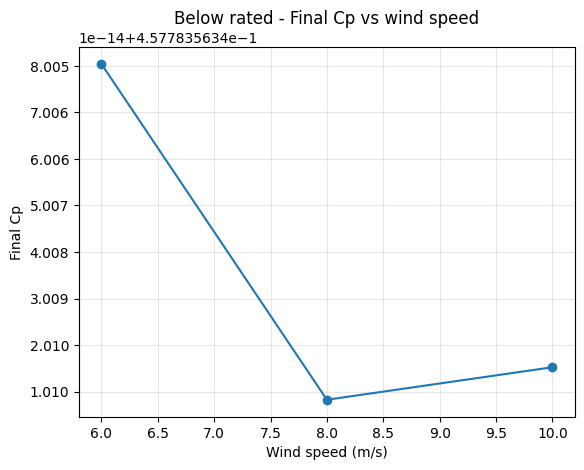

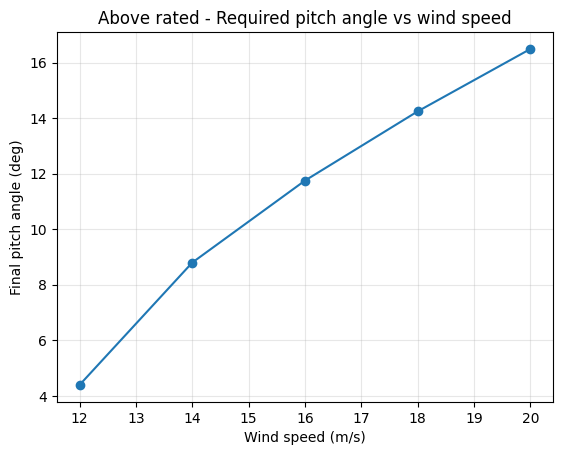

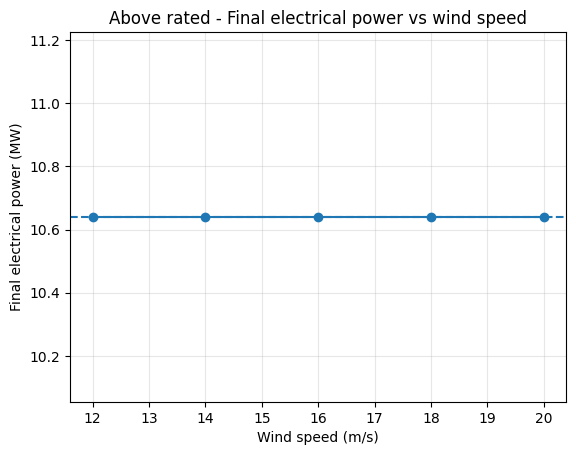

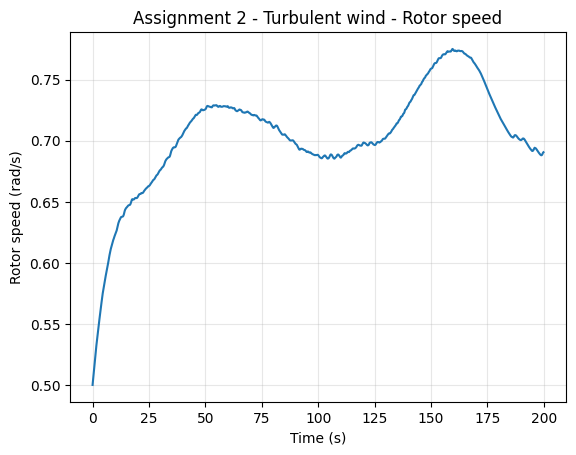

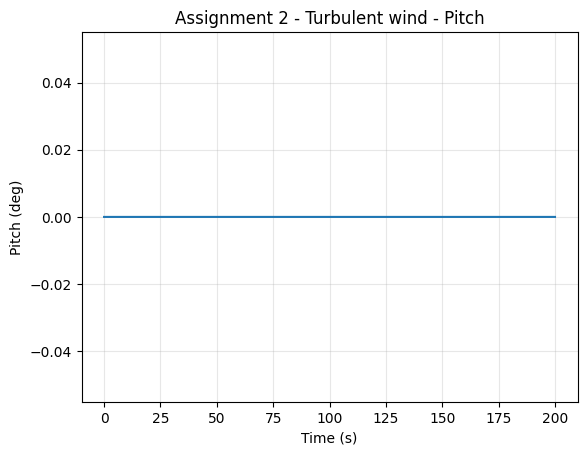

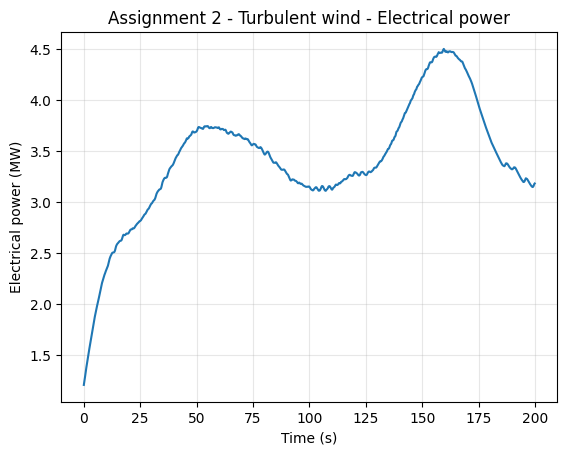

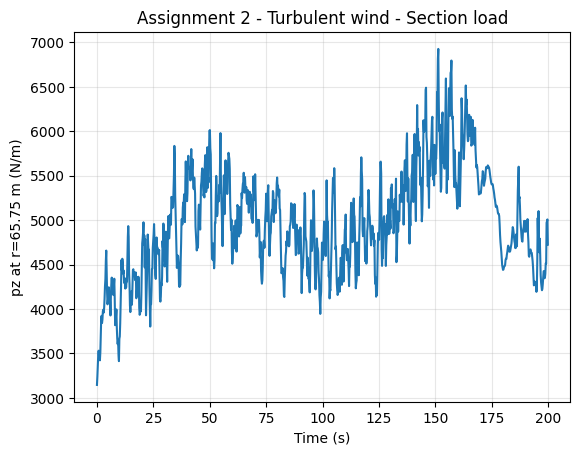

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field

# ============================================================
# 1) FILES
# ============================================================

DATA_DIR = "."

BLADE_FILE = os.path.join(DATA_DIR, "bladedat.txt")

AIRFOIL_FILES = {
    100.0: os.path.join(DATA_DIR, "cylinder_ds.txt"),
    24.1:  os.path.join(DATA_DIR, "FFA-W3-241_ds.txt"),
    30.1:  os.path.join(DATA_DIR, "FFA-W3-301_ds.txt"),
    36.0:  os.path.join(DATA_DIR, "FFA-W3-360_ds.txt"),
    48.0:  os.path.join(DATA_DIR, "FFA-W3-480_ds.txt"),
    60.0:  os.path.join(DATA_DIR, "FFA-W3-600_ds.txt"),
}

# Mann turbulence files
TURB_ZIP_FILE = os.path.join(DATA_DIR, "Turbulence_generator.zip")
TURB_EXTRACT_DIR = os.path.join(DATA_DIR, "Turbulence_generator")
TURB_INP_FILE = os.path.join(TURB_EXTRACT_DIR, "inputEx3.inp")
TURB_U_FILE = os.path.join(DATA_DIR, "sim1.bin")


# ============================================================
# 2) TURBINE + NUMERICAL CONSTANTS
# ============================================================

# Turbine data
R = 89.17                     # rotor radius [m]
B = 3                         # number of blades [-]
rho = 1.225                   # air density [kg/m^3]
H_HUB = 119.0                 # hub height [m]

# Numerical settings
Nsec = 40                     # number of blade sections
WARM_START = True             # initialize induction from steady BEM

# BEM solver settings
F_RELAX = 0.35
TOL_RES = 1e-4
ITMAX = 80

# Assignment 2 controller / drivetrain
P_RATED = 10.64e6             # rated electrical power [W]
I_DRIVETRAIN = 1.6e8          # drivetrain inertia [kg m^2]

K_P = 1.5                     # proportional gain
K_I = 0.64                    # integral gain
K_K_DEG = 14.0                # gain reduction constant [deg]

THETA_P_MIN_DEG = 0.0
THETA_P_MAX_DEG = 90.0

OMEGA_REF_MARGIN = 0.05       # omega_ref = omega_rated + margin [rad/s]

# Time settings
T_END_A2 = 200.0
DT_A2 = 0.15

# Mean wind for turbulence convection
VHUB_REF = 8.0

# Below-rated "optimal TSR" assumption
LAMBDA_OPT = 8.0


# ============================================================
# 3) RECORDERS
# ============================================================

@dataclass
class RecorderA2:
    t: list = field(default_factory=list)
    omega: list = field(default_factory=list)
    pitch_deg: list = field(default_factory=list)
    T_total: list = field(default_factory=list)
    P_mech_total: list = field(default_factory=list)
    P_el_total: list = field(default_factory=list)
    M_aero: list = field(default_factory=list)
    M_gen: list = field(default_factory=list)

    def record(self, t, omega, pitch_deg, T_total, P_mech_total, P_el_total, M_aero, M_gen):
        self.t.append(float(t))
        self.omega.append(float(omega))
        self.pitch_deg.append(float(pitch_deg))
        self.T_total.append(float(T_total))
        self.P_mech_total.append(float(P_mech_total))
        self.P_el_total.append(float(P_el_total))
        self.M_aero.append(float(M_aero))
        self.M_gen.append(float(M_gen))

    def as_arrays(self):
        return {
            "t": np.array(self.t, dtype=float),
            "omega": np.array(self.omega, dtype=float),
            "pitch_deg": np.array(self.pitch_deg, dtype=float),
            "T_total": np.array(self.T_total, dtype=float),
            "P_mech_total": np.array(self.P_mech_total, dtype=float),
            "P_el_total": np.array(self.P_el_total, dtype=float),
            "M_aero": np.array(self.M_aero, dtype=float),
            "M_gen": np.array(self.M_gen, dtype=float),
        }


# ============================================================
# 4) BLADE GEOMETRY
# ============================================================

def read_bladedat(path):
    # bladedat:
    # col 0 = radius [m]
    # col 1 = twist [deg]
    # col 2 = chord [m]
    # col 3 = t/c [%] or ratio

    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing blade file: {path}")

    data = np.loadtxt(path)
    if data.ndim != 2 or data.shape[1] < 4:
        raise ValueError("bladedat.txt must have at least 4 columns")

    r = data[:, 0]
    beta_deg = data[:, 1]
    c = data[:, 2]
    tc = data[:, 3]

    if np.nanmax(tc) <= 1.5:
        tc = tc * 100.0

    idx = np.argsort(r)
    return r[idx], c[idx], beta_deg[idx], tc[idx]


def build_sections(r_tab, c_tab, beta_deg_tab, tc_tab, nsec):
    r0 = float(np.min(r_tab))
    Rtip = float(np.max(r_tab))

    # avoid exact tip
    r_sec = np.linspace(r0, 0.98 * Rtip, nsec)

    c_sec = np.interp(r_sec, r_tab, c_tab)
    beta_deg_sec = np.interp(r_sec, r_tab, beta_deg_tab)
    tc_sec = np.interp(r_sec, r_tab, tc_tab)

    return Rtip, r_sec, c_sec, beta_deg_sec, tc_sec


# ============================================================
# 5) AIRFOIL POLARS
# ============================================================

def read_polar_file(path):
    tbl = np.loadtxt(path, ndmin=2)
    if tbl.shape[1] < 3:
        raise ValueError(f"{path} must have at least 3 columns")

    alpha = tbl[:, 0]
    cl = tbl[:, 1]
    cd = tbl[:, 2]

    order = np.argsort(alpha)
    return alpha[order], cl[order], cd[order]


def load_airfoils(files_dict):
    items = sorted(files_dict.items(), key=lambda kv: kv[0])
    thick = np.array([tc for tc, _ in items], dtype=float)

    aoa_cols, cl_cols, cd_cols = [], [], []
    for _, fname in items:
        if not os.path.exists(fname):
            raise FileNotFoundError(f"Missing airfoil file: {fname}")
        a, cl, cd = read_polar_file(fname)
        aoa_cols.append(a)
        cl_cols.append(cl)
        cd_cols.append(cd)

    return thick, aoa_cols, cl_cols, cd_cols


THICK, AOA_COLS, CL_COLS, CD_COLS = load_airfoils(AIRFOIL_FILES)


def interp_extrap(x, xp, yp):
    x = float(x)
    xp = np.asarray(xp, dtype=float)
    yp = np.asarray(yp, dtype=float)

    if x <= xp[0]:
        x0, x1 = xp[0], xp[1]
        y0, y1 = yp[0], yp[1]
        return y0 + (y1 - y0) * (x - x0) / (x1 - x0)

    if x >= xp[-1]:
        x0, x1 = xp[-2], xp[-1]
        y0, y1 = yp[-2], yp[-1]
        return y1 + (y1 - y0) * (x - x1) / (x1 - x0)

    return float(np.interp(x, xp, yp))


def cl_cd_double_interp(alpha_deg, tc_percent):
    tc = float(np.clip(tc_percent, THICK.min(), THICK.max()))

    cl_thk = np.empty(len(THICK))
    cd_thk = np.empty(len(THICK))

    for k in range(len(THICK)):
        cl_thk[k] = interp_extrap(alpha_deg, AOA_COLS[k], CL_COLS[k])
        cd_thk[k] = interp_extrap(alpha_deg, AOA_COLS[k], CD_COLS[k])

    cl = float(np.interp(tc, THICK, cl_thk))
    cd = float(np.interp(tc, THICK, cd_thk))
    return cl, cd


# ============================================================
# 6) BEM AERODYNAMICS
# ============================================================

def prandtl_tip_loss(B, r, R, phi):
    sphi = max(abs(np.sin(phi)), 1e-12)
    ftip = max((B * (R - r)) / (2.0 * r * sphi), 0.0)
    F = (2.0 / np.pi) * np.arccos(np.exp(-ftip))
    return float(np.clip(F, 1e-6, 1.0))


def solve_a_ap_qs(V0, Omega, r, chord, twist_deg, pitch_deg, tc_percent, a_init, ap_init):
    # phi   = inflow angle
    # alpha = angle of attack = phi - (twist + pitch)

    theta_p = np.deg2rad(pitch_deg)
    twist = np.deg2rad(twist_deg)

    a_new = 0.10 if a_init == 0.0 else a_init
    ap_new = 0.00 if ap_init == 0.0 else ap_init

    it = 0
    while True:
        it += 1
        a, ap = a_new, ap_new

        denom = (1.0 + ap) * Omega * r + 1e-12
        phi = np.arctan(((1.0 - a) * V0) / denom)
        alpha_deg = np.rad2deg(phi - (twist + theta_p))

        Cl, Cd = cl_cd_double_interp(alpha_deg, tc_percent)

        Cn = Cl * np.cos(phi) + Cd * np.sin(phi)
        Ct = Cl * np.sin(phi) - Cd * np.cos(phi)

        sigma = (B * chord) / (2.0 * np.pi * r + 1e-12)
        F = prandtl_tip_loss(B, r, R, phi)

        sphi = np.sin(phi)
        cphi = np.cos(phi)

        a_fix = (sigma * Cn * (1.0 - a)) / (4.0 * F * sphi**2 + 1e-12)
        ap_fix = (sigma * Ct * (1.0 + ap)) / (4.0 * F * sphi * cphi + 1e-12)

        # high-thrust correction
        if a > 0.33:
            dCT = ((1.0 - a)**2 * Cn * sigma) / (sphi**2 + 1e-12)
            a_fix = dCT / (4.0 * F * (1.0 - 0.25 * (5.0 - 3.0 * a) * a) + 1e-12)

        a_new = a + F_RELAX * (a_fix - a)
        ap_new = ap + F_RELAX * (ap_fix - ap)

        if max(abs(a_fix - a), abs(ap_fix - ap)) < TOL_RES or it >= ITMAX:
            return a_new, ap_new


def loads_from_a_ap(V0, Omega, r, chord, twist_deg, pitch_deg, tc_percent, a, ap):
    theta_p = np.deg2rad(pitch_deg)
    twist = np.deg2rad(twist_deg)

    denom = (1.0 + ap) * Omega * r + 1e-12
    phi = np.arctan(((1.0 - a) * V0) / denom)
    alpha_deg = np.rad2deg(phi - (twist + theta_p))

    Cl, Cd = cl_cd_double_interp(alpha_deg, tc_percent)

    # relative velocity
    Vrel = np.sqrt(((1.0 - a) * V0)**2 + ((1.0 + ap) * Omega * r)**2)

    # lift and drag per span
    L = 0.5 * rho * Vrel**2 * chord * Cl
    D = 0.5 * rho * Vrel**2 * chord * Cd

    # projections
    fT = L * np.sin(phi) - D * np.cos(phi)
    fN = L * np.cos(phi) + D * np.sin(phi)

    return fN, fT


def compute_blade_thrust_torque_power(fN, fT, r_sec, Omega):
    Tblade = np.trapezoid(fN, r_sec)
    Qblade = np.trapezoid(fT * r_sec, r_sec)
    Pblade = Omega * Qblade
    return Tblade, Qblade, Pblade


def warm_start_induction(a_state, ap_state, r_sec, c_sec, beta_deg_sec, tc_sec, Vz_local, pitch_deg, Omega):
    for j in range(len(r_sec)):
        a_state[j], ap_state[j] = solve_a_ap_qs(
            Vz_local[j], Omega, r_sec[j], c_sec[j], beta_deg_sec[j], pitch_deg, tc_sec[j],
            a_state[j], ap_state[j]
        )


# ============================================================
# 7) CONTROLLER + GENERATOR
# ============================================================

def generator_torque(Omega, K_gen, Omega_rated, P_rated):
    # below rated: M_gen = K * Omega^2
    # above rated: M_gen = P_rated / Omega

    Omega_eff = max(float(Omega), 1e-6)
    if Omega_eff < Omega_rated:
        return K_gen * Omega_eff**2
    return P_rated / Omega_eff


def electrical_power(M_gen, Omega):
    return M_gen * Omega


def pitch_controller_step(theta_int_deg, Omega, Omega_ref, dt):
    # PI controller on speed error
    err = Omega - Omega_ref

    gain_reduction = 1.0 + max(theta_int_deg, 0.0) / max(K_K_DEG, 1e-6)

    theta_p_term_deg = np.rad2deg(K_P * err) / gain_reduction
    theta_int_deg_new = theta_int_deg + np.rad2deg(K_I * err * dt) / gain_reduction

    theta_int_deg_new = np.clip(theta_int_deg_new, THETA_P_MIN_DEG, THETA_P_MAX_DEG)

    theta_set_deg = theta_p_term_deg + theta_int_deg_new
    theta_set_deg = np.clip(theta_set_deg, THETA_P_MIN_DEG, THETA_P_MAX_DEG)

    return theta_set_deg, theta_int_deg_new


def steady_power_for_operating_point(V0, Omega, pitch_deg, r_sec, c_sec, beta_deg_sec, tc_sec):
    a_state = np.zeros(len(r_sec))
    ap_state = np.zeros(len(r_sec))
    Vz_local = np.full_like(r_sec, V0)

    if WARM_START:
        warm_start_induction(a_state, ap_state, r_sec, c_sec, beta_deg_sec, tc_sec, Vz_local, pitch_deg, Omega)

    fN = np.zeros_like(r_sec)
    fT = np.zeros_like(r_sec)

    for j in range(len(r_sec)):
        a_qs, ap_qs = solve_a_ap_qs(
            V0, Omega, r_sec[j], c_sec[j], beta_deg_sec[j], pitch_deg, tc_sec[j],
            a_state[j], ap_state[j]
        )
        a_state[j], ap_state[j] = a_qs, ap_qs

        fN[j], fT[j] = loads_from_a_ap(
            V0, Omega, r_sec[j], c_sec[j], beta_deg_sec[j], pitch_deg, tc_sec[j],
            a_state[j], ap_state[j]
        )

    _, Qblade, _ = compute_blade_thrust_torque_power(fN, fT, r_sec, Omega)
    Qaero_total = B * Qblade
    Paero_total = Qaero_total * Omega
    return Paero_total


def find_rated_operating_point(r_sec, c_sec, beta_deg_sec, tc_sec,
                               lambda_opt=LAMBDA_OPT, v_min=4.0, v_max=20.0, nV=50):
    V_vec = np.linspace(v_min, v_max, nV)
    P_vec = np.zeros_like(V_vec)

    for i, V0 in enumerate(V_vec):
        Omega = lambda_opt * V0 / R
        P_vec[i] = steady_power_for_operating_point(
            V0, Omega, 0.0, r_sec, c_sec, beta_deg_sec, tc_sec
        )

    idx = np.argmax(P_vec >= P_RATED)
    if P_vec[idx] < P_RATED:
        raise RuntimeError("Could not find rated wind speed in chosen range")

    V_rated = V_vec[idx]
    Omega_rated = lambda_opt * V_rated / R

    # continuity at rated:
    # P_rated = K * Omega_rated^3
    K_gen = P_RATED / (Omega_rated**3)

    Omega_ref = Omega_rated + OMEGA_REF_MARGIN

    return {
        "V_rated": V_rated,
        "Omega_rated": Omega_rated,
        "Omega_ref": Omega_ref,
        "K_gen": K_gen,
        "V_vec": V_vec,
        "P_vec": P_vec,
    }


# ============================================================
# 8) TURBULENCE INPUTS
# ============================================================

def ensure_turbulence_files_exist():
    if os.path.exists(TURB_U_FILE):
        return

    if not os.path.exists(TURB_ZIP_FILE):
        raise FileNotFoundError("No sim1.bin found and turbulence zip is missing")

    os.makedirs(TURB_EXTRACT_DIR, exist_ok=True)

    import zipfile
    with zipfile.ZipFile(TURB_ZIP_FILE, "r") as zf:
        zf.extractall(DATA_DIR)

    sim1_extracted = os.path.join(TURB_EXTRACT_DIR, "sim1.bin")
    if not os.path.exists(sim1_extracted):
        raise FileNotFoundError("Could not find sim1.bin after extracting zip")

    if not os.path.exists(TURB_U_FILE):
        try:
            import shutil
            shutil.copy(sim1_extracted, TURB_U_FILE)
        except Exception:
            pass


def read_mann_inp(path):
    if not os.path.exists(path):
        return None

    lines = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for ln in f:
            ln = ln.strip()
            if ln:
                lines.append(ln)

    if len(lines) < 10:
        return None

    n1 = int(float(lines[3]))
    n2 = int(float(lines[4]))
    n3 = int(float(lines[5]))
    Lx = float(lines[6])
    Ly = float(lines[7])
    Lz = float(lines[8])

    return {"n1": n1, "n2": n2, "n3": n3, "Lx": Lx, "Ly": Ly, "Lz": Lz}


def load_mann_bin_3d(filename, n1, n2, n3):
    data = np.fromfile(filename, dtype=np.dtype("<f4"), count=n1 * n2 * n3)
    if data.size != n1 * n2 * n3:
        raise ValueError(f"{filename} size does not match n1*n2*n3")
    return data.reshape((n1, n2, n3), order="C")


def bilinear_interp_plane(u_plane, y_grid, z_grid, y_pos, z_pos):
    y_grid = np.asarray(y_grid, dtype=float)
    z_grid = np.asarray(z_grid, dtype=float)
    y_pos = np.asarray(y_pos, dtype=float)
    z_pos = np.asarray(z_pos, dtype=float)

    ny = len(y_grid)
    nz = len(z_grid)

    y_pos_c = np.clip(y_pos, y_grid[0], y_grid[-1])
    z_pos_c = np.clip(z_pos, z_grid[0], z_grid[-1])

    iy = np.searchsorted(y_grid, y_pos_c) - 1
    iz = np.searchsorted(z_grid, z_pos_c) - 1

    iy = np.clip(iy, 0, ny - 2)
    iz = np.clip(iz, 0, nz - 2)

    y0 = y_grid[iy]
    y1 = y_grid[iy + 1]
    z0 = z_grid[iz]
    z1 = z_grid[iz + 1]

    ty = (y_pos_c - y0) / np.maximum(y1 - y0, 1e-12)
    tz = (z_pos_c - z0) / np.maximum(z1 - z0, 1e-12)

    v00 = u_plane[iy, iz]
    v10 = u_plane[iy + 1, iz]
    v01 = u_plane[iy, iz + 1]
    v11 = u_plane[iy + 1, iz + 1]

    v0 = v00 * (1.0 - ty) + v10 * ty
    v1 = v01 * (1.0 - ty) + v11 * ty

    return v0 * (1.0 - tz) + v1 * tz


# ============================================================
# 9) ASSIGNMENT 2 - UNIFORM WIND
# ============================================================

def run_A2_uniform(r_sec, c_sec, beta_deg_sec, tc_sec,
                   V0=15.0,
                   omega_init=0.5,
                   pitch_init_deg=0.0,
                   T_end=T_END_A2,
                   dt=DT_A2):
    rated = find_rated_operating_point(r_sec, c_sec, beta_deg_sec, tc_sec)
    K_gen = rated["K_gen"]
    omega_rated = rated["Omega_rated"]
    omega_ref = rated["Omega_ref"]

    n_steps = int(np.floor(T_end / dt)) + 1

    a_state = np.zeros(len(r_sec))
    ap_state = np.zeros(len(r_sec))

    omega_t = omega_init
    pitch_deg = pitch_init_deg
    theta_int_deg = pitch_init_deg

    Vz_local = np.full_like(r_sec, V0)

    if WARM_START:
        warm_start_induction(
            a_state, ap_state, r_sec, c_sec, beta_deg_sec, tc_sec,
            Vz_local, pitch_deg, omega_t
        )

    rec = RecorderA2()

    for k in range(n_steps):
        t = k * dt

        fN = np.zeros_like(r_sec)
        fT = np.zeros_like(r_sec)

        for j in range(len(r_sec)):
            a_qs, ap_qs = solve_a_ap_qs(
                V0, omega_t, r_sec[j], c_sec[j], beta_deg_sec[j], pitch_deg, tc_sec[j],
                a_state[j], ap_state[j]
            )
            a_state[j], ap_state[j] = a_qs, ap_qs

            fN[j], fT[j] = loads_from_a_ap(
                V0, omega_t, r_sec[j], c_sec[j], beta_deg_sec[j], pitch_deg, tc_sec[j],
                a_state[j], ap_state[j]
            )

        Tblade, Qblade, Pblade = compute_blade_thrust_torque_power(fN, fT, r_sec, omega_t)

        T_total = B * Tblade
        M_aero = B * Qblade
        P_mech_total = B * Pblade

        M_gen = generator_torque(omega_t, K_gen, omega_rated, P_RATED)
        P_el_total = electrical_power(M_gen, omega_t)

        # I * domega/dt = M_aero - M_gen
        domega_dt = (M_aero - M_gen) / I_DRIVETRAIN
        omega_next = max(0.0, omega_t + dt * domega_dt)

        if omega_t >= omega_rated:
            pitch_next_deg, theta_int_deg = pitch_controller_step(
                theta_int_deg, omega_t, omega_ref, dt
            )
        else:
            pitch_next_deg = 0.0
            theta_int_deg = 0.0

        pitch_next_deg = float(np.clip(pitch_next_deg, THETA_P_MIN_DEG, THETA_P_MAX_DEG))

        rec.record(t, omega_t, pitch_deg, T_total, P_mech_total, P_el_total, M_aero, M_gen)

        pitch_deg = pitch_next_deg
        omega_t = omega_next

    out = rec.as_arrays()
    out["K_gen"] = K_gen
    out["omega_rated"] = omega_rated
    out["omega_ref"] = omega_ref
    out["V_rated"] = rated["V_rated"]
    out["V0"] = V0
    return out


# ============================================================
# 10) ASSIGNMENT 2 - TURBULENT WIND
# ============================================================

def run_A2_turbulent(r_sec, c_sec, beta_deg_sec, tc_sec,
                     omega_init=0.5,
                     pitch_init_deg=0.0,
                     r_probe=65.75,
                     T_end=T_END_A2):
    ensure_turbulence_files_exist()

    rated = find_rated_operating_point(r_sec, c_sec, beta_deg_sec, tc_sec)
    K_gen = rated["K_gen"]
    omega_rated = rated["Omega_rated"]
    omega_ref = rated["Omega_ref"]

    inp = read_mann_inp(TURB_INP_FILE)
    if inp is None:
        n1, n2, n3 = 4096, 32, 32
        Lx, Ly, Lz = 6142.5, 180.0, 180.0
    else:
        n1, n2, n3 = inp["n1"], inp["n2"], inp["n3"]
        Lx, Ly, Lz = inp["Lx"], inp["Ly"], inp["Lz"]

    ufile = TURB_U_FILE
    if not os.path.exists(ufile):
        ufile2 = os.path.join(TURB_EXTRACT_DIR, "sim1.bin")
        if os.path.exists(ufile2):
            ufile = ufile2
        else:
            raise FileNotFoundError("Could not find sim1.bin")

    u_box = load_mann_bin_3d(ufile, n1, n2, n3)

    dx = Lx / (n1 - 1)
    dy = Ly / (n2 - 1)
    dz = Lz / (n3 - 1)

    dt_turb = dx / max(VHUB_REF, 0.1)

    y_grid = (np.arange(n2) * dy) - ((n2 - 1) * dy) / 2.0
    z_grid = H_HUB + (np.arange(n3) * dz) - ((n3 - 1) * dz) / 2.0

    n_steps = int(np.floor(T_end / dt_turb)) + 1
    n_steps = min(n_steps, n1)

    a_state = np.zeros((B, len(r_sec)))
    ap_state = np.zeros((B, len(r_sec)))

    omega_t = omega_init
    pitch_deg = pitch_init_deg
    theta_int_deg = pitch_init_deg

    if WARM_START:
        for b in range(B):
            Vz_local_ws = np.full_like(r_sec, VHUB_REF)
            warm_start_induction(
                a_state[b], ap_state[b], r_sec, c_sec, beta_deg_sec, tc_sec,
                Vz_local_ws, pitch_deg, omega_t
            )

    rec = RecorderA2()
    pz_probe_hist = []

    for n in range(n_steps):
        t = n * dt_turb
        u_plane = u_box[n, :, :]

        T_b = np.zeros(B)
        Q_b = np.zeros(B)

        for b in range(B):
            azim = omega_t * t + 2.0 * np.pi * b / B

            y_pos = r_sec * np.sin(azim)
            z_pos = H_HUB + r_sec * np.cos(azim)

            u_turb = bilinear_interp_plane(u_plane, y_grid, z_grid, y_pos, z_pos)
            Vz_local = np.maximum(VHUB_REF + u_turb, 0.1)

            fN = np.zeros_like(r_sec)
            fT = np.zeros_like(r_sec)

            for j in range(len(r_sec)):
                a_qs, ap_qs = solve_a_ap_qs(
                    Vz_local[j], omega_t, r_sec[j], c_sec[j], beta_deg_sec[j], pitch_deg, tc_sec[j],
                    a_state[b, j], ap_state[b, j]
                )
                a_state[b, j], ap_state[b, j] = a_qs, ap_qs

                fN[j], fT[j] = loads_from_a_ap(
                    Vz_local[j], omega_t, r_sec[j], c_sec[j], beta_deg_sec[j], pitch_deg, tc_sec[j],
                    a_state[b, j], ap_state[b, j]
                )

            T_b[b], Q_b[b], _ = compute_blade_thrust_torque_power(fN, fT, r_sec, omega_t)

            if b == 0:
                pz_probe_hist.append(np.interp(r_probe, r_sec, fN))

        T_total = np.sum(T_b)
        M_aero = np.sum(Q_b)
        P_mech_total = M_aero * omega_t

        M_gen = generator_torque(omega_t, K_gen, omega_rated, P_RATED)
        P_el_total = electrical_power(M_gen, omega_t)

        domega_dt = (M_aero - M_gen) / I_DRIVETRAIN
        omega_next = max(0.0, omega_t + dt_turb * domega_dt)

        if omega_t >= omega_rated:
            pitch_next_deg, theta_int_deg = pitch_controller_step(
                theta_int_deg, omega_t, omega_ref, dt_turb
            )
        else:
            pitch_next_deg = 0.0
            theta_int_deg = 0.0

        pitch_next_deg = float(np.clip(pitch_next_deg, THETA_P_MIN_DEG, THETA_P_MAX_DEG))

        rec.record(t, omega_t, pitch_deg, T_total, P_mech_total, P_el_total, M_aero, M_gen)

        pitch_deg = pitch_next_deg
        omega_t = omega_next

    out = rec.as_arrays()
    out["K_gen"] = K_gen
    out["omega_rated"] = omega_rated
    out["omega_ref"] = omega_ref
    out["V_rated"] = rated["V_rated"]
    out["dt_turb"] = dt_turb
    out["pz_probe"] = np.array(pz_probe_hist, dtype=float)
    return out


# ============================================================
# 11) Q1 SWEEPS (THE MISSING PART)
# ============================================================

def run_below_rated_sweep(r_sec, c_sec, beta_deg_sec, tc_sec, wind_speeds):
    """
    Runs several below-rated uniform wind cases and returns final:
    - pitch
    - omega
    - TSR
    - Cp

    This is used to answer:
    "show that below rated the steady result ends at the maximum Cp"
    """
    rows = []

    for V0 in wind_speeds:
        omega_init = LAMBDA_OPT * V0 / R

        out = run_A2_uniform(
            r_sec, c_sec, beta_deg_sec, tc_sec,
            V0=V0,
            omega_init=omega_init,
            pitch_init_deg=0.0
        )

        omega_final = out["omega"][-1]
        pitch_final = out["pitch_deg"][-1]
        P_mech_final = out["P_mech_total"][-1]

        lambda_final = omega_final * R / V0

        area = np.pi * R**2
        Cp_final = P_mech_final / (0.5 * rho * area * V0**3)

        rows.append({
            "V0": V0,
            "omega_final": omega_final,
            "pitch_final": pitch_final,
            "lambda_final": lambda_final,
            "Cp_final": Cp_final,
        })

    return rows


def run_above_rated_sweep(r_sec, c_sec, beta_deg_sec, tc_sec, wind_speeds):
    """
    Runs several above-rated uniform wind cases and returns final:
    - pitch
    - omega
    - electrical power

    This is used to answer:
    "determine necessary pitch angles theta_p(V0) above rated"
    """
    rows = []

    for V0 in wind_speeds:
        out = run_A2_uniform(
            r_sec, c_sec, beta_deg_sec, tc_sec,
            V0=V0,
            omega_init=0.5,
            pitch_init_deg=0.0
        )

        rows.append({
            "V0": V0,
            "pitch_final": out["pitch_deg"][-1],
            "omega_final": out["omega"][-1],
            "P_el_final_MW": out["P_el_total"][-1] / 1e6,
        })

    return rows


# ============================================================
# 12) PLOTS FOR ASSIGNMENT 2
# ============================================================

def plot_A2_uniform(out):
    outdir = "pdf_plots"
    os.makedirs(outdir, exist_ok=True)

    plt.figure()
    plt.plot(out["t"], out["omega"])
    plt.xlabel("Time (s)")
    plt.ylabel("Rotor speed (rad/s)")
    plt.title("Assignment 2 - Uniform wind - Rotor speed")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(outdir, "A2_uniform_omega.pdf"), bbox_inches="tight")

    plt.figure()
    plt.plot(out["t"], out["pitch_deg"])
    plt.xlabel("Time (s)")
    plt.ylabel("Pitch (deg)")
    plt.title("Assignment 2 - Uniform wind - Pitch")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(outdir, "A2_uniform_pitch.pdf"), bbox_inches="tight")

    plt.figure()
    plt.plot(out["t"], out["P_mech_total"] / 1e6, label="Mechanical")
    plt.plot(out["t"], out["P_el_total"] / 1e6, label="Electrical")
    plt.xlabel("Time (s)")
    plt.ylabel("Power (MW)")
    plt.title("Assignment 2 - Uniform wind - Power")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(outdir, "A2_uniform_power.pdf"), bbox_inches="tight")


def plot_A2_turbulent(out):
    outdir = "pdf_plots"
    os.makedirs(outdir, exist_ok=True)

    plt.figure()
    plt.plot(out["t"], out["omega"])
    plt.xlabel("Time (s)")
    plt.ylabel("Rotor speed (rad/s)")
    plt.title("Assignment 2 - Turbulent wind - Rotor speed")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(outdir, "A2_turbulent_omega.pdf"), bbox_inches="tight")

    plt.figure()
    plt.plot(out["t"], out["pitch_deg"])
    plt.xlabel("Time (s)")
    plt.ylabel("Pitch (deg)")
    plt.title("Assignment 2 - Turbulent wind - Pitch")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(outdir, "A2_turbulent_pitch.pdf"), bbox_inches="tight")

    plt.figure()
    plt.plot(out["t"], out["P_el_total"] / 1e6)
    plt.xlabel("Time (s)")
    plt.ylabel("Electrical power (MW)")
    plt.title("Assignment 2 - Turbulent wind - Electrical power")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(outdir, "A2_turbulent_power.pdf"), bbox_inches="tight")

    plt.figure()
    plt.plot(out["t"], out["pz_probe"])
    plt.xlabel("Time (s)")
    plt.ylabel("pz at r=65.75 m (N/m)")
    plt.title("Assignment 2 - Turbulent wind - Section load")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(outdir, "A2_turbulent_pz.pdf"), bbox_inches="tight")


def plot_below_rated_results(rows):
    outdir = "pdf_plots"
    os.makedirs(outdir, exist_ok=True)

    V = np.array([r["V0"] for r in rows], dtype=float)
    TSR = np.array([r["lambda_final"] for r in rows], dtype=float)
    Cp = np.array([r["Cp_final"] for r in rows], dtype=float)

    plt.figure()
    plt.plot(V, TSR, marker="o")
    plt.xlabel("Wind speed (m/s)")
    plt.ylabel("Final TSR")
    plt.title("Below rated - Final TSR vs wind speed")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(outdir, "A2_below_rated_TSR.pdf"), bbox_inches="tight")

    plt.figure()
    plt.plot(V, Cp, marker="o")
    plt.xlabel("Wind speed (m/s)")
    plt.ylabel("Final Cp")
    plt.title("Below rated - Final Cp vs wind speed")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(outdir, "A2_below_rated_Cp.pdf"), bbox_inches="tight")


def plot_above_rated_pitch_curve(rows):
    outdir = "pdf_plots"
    os.makedirs(outdir, exist_ok=True)

    V = np.array([r["V0"] for r in rows], dtype=float)
    pitch = np.array([r["pitch_final"] for r in rows], dtype=float)
    Pel = np.array([r["P_el_final_MW"] for r in rows], dtype=float)

    plt.figure()
    plt.plot(V, pitch, marker="o")
    plt.xlabel("Wind speed (m/s)")
    plt.ylabel("Final pitch angle (deg)")
    plt.title("Above rated - Required pitch angle vs wind speed")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(outdir, "A2_above_rated_pitch_curve.pdf"), bbox_inches="tight")

    plt.figure()
    plt.plot(V, Pel, marker="o")
    plt.axhline(P_RATED / 1e6, linestyle="--")
    plt.xlabel("Wind speed (m/s)")
    plt.ylabel("Final electrical power (MW)")
    plt.title("Above rated - Final electrical power vs wind speed")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(outdir, "A2_above_rated_power_check.pdf"), bbox_inches="tight")


# ============================================================
# 13) MAIN
# ============================================================

def main():
    # Read blade and build radial sections
    r_tab, c_tab, beta_deg_tab, tc_tab = read_bladedat(BLADE_FILE)
    _, r_sec, c_sec, beta_deg_sec, tc_sec = build_sections(
        r_tab, c_tab, beta_deg_tab, tc_tab, Nsec
    )

    # --------------------------------------------------------
    # Find rated operating point and controller constants
    # --------------------------------------------------------
    rated = find_rated_operating_point(r_sec, c_sec, beta_deg_sec, tc_sec)

    # --------------------------------------------------------
    # Q1: one example above-rated uniform case
    # --------------------------------------------------------
    out_uniform = run_A2_uniform(
        r_sec, c_sec, beta_deg_sec, tc_sec,
        V0=15.0,
        omega_init=0.5,
        pitch_init_deg=0.0
    )
    plot_A2_uniform(out_uniform)

    # --------------------------------------------------------
    # Q1 missing part: below-rated sweep
    # --------------------------------------------------------
    below_winds = [6.0, 8.0, 10.0]
    below_rows = run_below_rated_sweep(r_sec, c_sec, beta_deg_sec, tc_sec, below_winds)
    plot_below_rated_results(below_rows)

    # --------------------------------------------------------
    # Q1 missing part: above-rated pitch-angle curve
    # --------------------------------------------------------
    above_winds = [12.0, 14.0, 16.0, 18.0, 20.0]
    above_rows = run_above_rated_sweep(r_sec, c_sec, beta_deg_sec, tc_sec, above_winds)
    plot_above_rated_pitch_curve(above_rows)

    # --------------------------------------------------------
    # Q2: turbulent wind with controller
    # --------------------------------------------------------
    out_turb = run_A2_turbulent(
        r_sec, c_sec, beta_deg_sec, tc_sec,
        omega_init=0.5,
        pitch_init_deg=0.0,
        r_probe=65.75
    )
    plot_A2_turbulent(out_turb)

    # --------------------------------------------------------
    # Print useful results
    # --------------------------------------------------------
    print("Assignment 2 constants:")
    print("K_gen       =", rated["K_gen"])
    print("omega_rated =", rated["Omega_rated"])
    print("omega_ref   =", rated["Omega_ref"])
    print("V_rated     =", rated["V_rated"])

    print("\nExample above-rated case at 15 m/s:")
    print("Final mechanical power [MW] =", out_uniform["P_mech_total"][-1] / 1e6)
    print("Final electrical power [MW] =", out_uniform["P_el_total"][-1] / 1e6)
    print("Final pitch [deg]           =", out_uniform["pitch_deg"][-1])
    print("Rated power target [MW]     =", P_RATED / 1e6)

    print("\nBelow-rated sweep:")
    for row in below_rows:
        print(
            f"V={row['V0']:.1f} m/s, "
            f"omega={row['omega_final']:.4f} rad/s, "
            f"pitch={row['pitch_final']:.3f} deg, "
            f"TSR={row['lambda_final']:.3f}, "
            f"Cp={row['Cp_final']:.4f}"
        )

    print("\nAbove-rated sweep:")
    for row in above_rows:
        print(
            f"V={row['V0']:.1f} m/s, "
            f"pitch={row['pitch_final']:.3f} deg, "
            f"omega={row['omega_final']:.4f} rad/s, "
            f"P_el={row['P_el_final_MW']:.4f} MW"
        )

    print("\nAssignment 2 turbulent:")
    print("Final electrical power [MW] =", out_turb["P_el_total"][-1] / 1e6)
    print("Mean last 20 s elec. [MW]   =", np.mean(out_turb["P_el_total"][-int(20.0 / out_turb["dt_turb"]):]) / 1e6)

    plt.show()


if __name__ == "__main__":
    main()